In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
cal_df = pd.read_csv('/content/calendar.csv')
cal_df.shape

(1969, 14)

In [ ]:
sales_train = pd.read_csv('/content/sales_train_evaluation.csv')
sales_train.shape

(30490, 1947)

In [ ]:
sell_prices = pd.read_csv('/content/sell_prices.csv')
sell_prices.shape

(6841121, 4)

Downcasting code

In [ ]:
def reduce_mem_usage(df):
    for col in df.columns:
        col_type = df[col].dtype

        # Skip if already categorical
        if str(col_type) == 'category':
            continue

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
        else:
            df[col] = df[col].astype('category')
    return df

In [ ]:
sales_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), object(6)
memory usage: 452.9+ MB


note : Melting the dataset to the desired for 5 years only .

In [ ]:
# downcasting the all the df
sales_train = reduce_mem_usage(sales_train)
sell_prices = reduce_mem_usage(sell_prices)
cal_df = reduce_mem_usage(cal_df)

NOte : left join ,right , inner join

Left Join (how='left'): You keep all 100 students from List A. If a student's address is found in List B, you attach it. If an address is missing, you still keep the student and just leave the address blank. No exam score is ever thrown away.

Inner Join (how='inner'): You only keep students who are present in both lists. If 5 students don't have an address in List B, those 5 students and their exam scores are completely deleted from your data.

Right Join (how='right'): You keep all addresses from List B, even if those people didn't take the exam. This creates extra blank rows you don't care about.

Since your main goal is to predict sales for every single row in df, you use how='left' s

In [ ]:
# Left Join (how='left'): You keep all 100 students from List A. If a student's address is found in List B, you attach it. If an address is missing, you still keep the student and just leave the address blank. No exam score is ever thrown away.

# Inner Join (how='inner'): You only keep students who are present in both lists. If 5 students don't have an address in List B, those 5 students and their exam scores are completely deleted from your data.

# Right Join (how='right'): You keep all addresses from List B, even if those people didn't take the exam. This creates extra blank rows you don't care about.

# Since your main goal is to predict sales for every single row in df, you use how='left' s

In [ ]:
import pandas as pd
import gc

# Define ID columns and value columns (taking only the last 365 days to preserve RAM)
id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
# For all days, use: [c for c in sales_train.columns if c.startswith('d_')]
day_cols = [f'd_{i}' for i in range(1577, 1942)]  # Last 1 year of data

# Ensure categorical types on ID columns before melting
for col in id_vars:
    if col in sales_train.columns:
        sales_train[col] = sales_train[col].astype('category')

# Perform the melt
df_melted = pd.melt(
    sales_train,
    id_vars=id_vars,
    value_vars=day_cols,
    var_name='d',
    value_name='sales'
)

# Optimize memory of melted columns
df_melted['d'] = df_melted['d'].astype('category')
df_melted['sales'] = df_melted['sales'].astype('int16')

# Delete wide DataFrame to free RAM and run garbage collection
del sales_train
gc.collect()

# Save melted data immediately to Parquet
df_melted.to_parquet('/content/sales_melted.parquet', index=False)
print("Melt complete and saved to sales_melted.parquet!")

Melt complete and saved to sales_melted.parquet!


In [ ]:
import pandas as pd
import gc

# Load Parquet files
df = pd.read_parquet('/content/sales_melted.parquet')
cal_df = pd.read_parquet('/content/cal_df.parquet')
sell_prices = pd.read_parquet('/content/sell_prices.parquet')

# Merge Calendar info (on column 'd')
df = df.merge(cal_df, on='d', how='left')

# Merge Sell Prices (on 'store_id', 'item_id', 'wm_yr_wk')
df = df.merge(sell_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

# Free RAM
del cal_df, sell_prices
gc.collect()

0

In [ ]:
df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1577,0,2015-05-24,11517,...,5,2015,None,None,None,None,0,0,0,8.26
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1577,0,2015-05-24,11517,...,5,2015,None,None,None,None,0,0,0,3.97
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1577,0,2015-05-24,11517,...,5,2015,None,None,None,None,0,0,0,2.97
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1577,2,2015-05-24,11517,...,5,2015,None,None,None,None,0,0,0,4.64
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1577,3,2015-05-24,11517,...,5,2015,None,None,None,None,0,0,0,2.88


In [ ]:
import pandas as pd
import numpy as np

# 1. Sort by item and day to calculate lags correctly
df['d_num'] = df['d'].str.replace('d_', '').astype('int16')
df = df.sort_values(by=['id', 'd_num']).reset_index(drop=True)

In [ ]:
# maintaing th lags of 28 and 34 days
df['lag_28' ] = df.groupby('id')['sales'].shift(28)
df['lag_34' ] = df.groupby('id')['sales'].shift(34)

/tmp/ipykernel_23434/269012171.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['lag_28' ] = df.groupby('id')['sales'].shift(28)
/tmp/ipykernel_23434/269012171.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['lag_34' ] = df.groupby('id')['sales'].shift(34)


In [ ]:
df['lag_28']

,lag_28
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
11128845,0.0
11128846,0.0
11128847,0.0
11128848,0.0


lag_28: Tells the model "How many units were sold exactly 28 days ago?

rolling().mean() (Rolling Mean) Does

While a single lag gives you a snapshot of one specific day in the past, a rolling mean calculates the average sales over a moving window of day

In [ ]:
# 7-day rolling average of sales from 28 days ago
df['rolling_mean_7'] = df.groupby('id')['lag_28'].transform(lambda x: x.rolling(7).mean())

# 28-day rolling average (captures a full 4-week trend)
df['rolling_mean_28'] = df.groupby('id')['lag_28'].transform(lambda x: x.rolling(28).mean())

/tmp/ipykernel_23434/3820950244.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['rolling_mean_7'] = df.groupby('id')['lag_28'].transform(lambda x: x.rolling(7).mean())
/tmp/ipykernel_23434/3820950244.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['rolling_mean_28'] = df.groupby('id')['lag_28'].transform(lambda x: x.rolling(28).mean())


In [ ]:
# 1. Fill missing event tags with a string label
event_cols = ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']
for col in event_cols:
    df[col] = df[col].astype(str).fillna('none').astype('category')

# 2. Downcast lag features
lag_cols = ['lag_28', 'lag_34', 'rolling_mean_7', 'rolling_mean_28']
for col in lag_cols:
    df[col] = df[col].astype('float32')

# 3. Drop ONLY the initial rows where lag features are NaN (due to shift)
df = df.dropna(subset=lag_cols).reset_index(drop=True)

print("Features engineered successfully! Valid Shape:", df.shape)

Features engineered successfully! Valid Shape: (9451900, 27)


In [ ]:
df

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,d_num,lag_28,lag_34,rolling_mean_7,rolling_mean_28
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1632,2,2015-07-18,11525,...,None,0,0,0,2.24,1632,0.0,2.0,0.571429,0.714286
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1633,3,2015-07-19,11525,...,None,0,0,0,2.24,1633,1.0,1.0,0.428571,0.750000
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1634,0,2015-07-20,11525,...,None,0,0,0,2.24,1634,0.0,0.0,0.285714,0.750000
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1635,0,2015-07-21,11525,...,None,0,0,0,2.24,1635,0.0,0.0,0.285714,0.750000
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1636,0,2015-07-22,11525,...,None,0,0,0,2.24,1636,0.0,0.0,0.285714,0.714286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9451895,HOUSEHOLD_2_516_WI_3_evaluation,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,WI_3,WI,d_1937,0,2016-05-18,11616,...,None,0,0,0,NaN,1937,0.0,0.0,0.000000,0.000000
9451896,HOUSEHOLD_2_516_WI_3_evaluation,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,WI_3,WI,d_1938,0,2016-05-19,11616,...,None,0,0,0,NaN,1938,0.0,0.0,0.000000,0.000000
9451897,HOUSEHOLD_2_516_WI_3_evaluation,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,WI_3,WI,d_1939,0,2016-05-20,11616,...,None,0,0,0,NaN,1939,0.0,0.0,0.000000,0.000000
9451898,HOUSEHOLD_2_516_WI_3_evaluation,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,WI_3,WI,d_1940,0,2016-05-21,11617,...,None,0,0,0,NaN,1940,0.0,0.0,0.000000,0.000000


In [ ]:
# 1. Fill missing event tags with a string label
event_cols = ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']
for col in event_cols:
    df[col] = df[col].astype(str).fillna('none').astype('category')

# 2. Downcast lag features
lag_cols = ['lag_28', 'lag_34', 'rolling_mean_7', 'rolling_mean_28']
for col in lag_cols:
    df[col] = df[col].astype('float32')

# 3. Drop ONLY the initial rows where lag features are NaN (due to shift)
df = df.dropna(subset=lag_cols).reset_index(drop=True)

print("Features engineered successfully! Valid Shape:", df.shape)

Features engineered successfully! Valid Shape: (9451900, 27)


In [ ]:
import pandas as pd
import numpy as np
import gc

# 1. Reload the merged data (or re-merge from saved parquets)
df = pd.read_parquet('/content/sales_melted.parquet')
cal_df = pd.read_parquet('/content/cal_df.parquet')
sell_prices = pd.read_parquet('/content/sell_prices.parquet')

df = df.merge(cal_df, on='d', how='left')
df = df.merge(sell_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
del cal_df, sell_prices
gc.collect()

# 2. Sort by item and day
df['d_num'] = df['d'].str.replace('d_', '').astype('int16')
df = df.sort_values(by=['id', 'd_num']).reset_index(drop=True)

# 3. Handle event missing values using fillna BEFORE categorical conversion
event_cols = ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']
for col in event_cols:
    df[col] = df[col].astype(str).replace('nan', 'none').fillna('none').astype('category')

# 4. Create Lag & Rolling Features
df['lag_28'] = df.groupby('id')['sales'].shift(28)
df['lag_34'] = df.groupby('id')['sales'].shift(34)
df['rolling_mean_7'] = df.groupby('id')['lag_28'].transform(lambda x: x.rolling(7).mean())
df['rolling_mean_28'] = df.groupby('id')['lag_28'].transform(lambda x: x.rolling(28).mean())

# 5. Downcast engineered lag features
lag_cols = ['lag_28', 'lag_34', 'rolling_mean_7', 'rolling_mean_28']
for col in lag_cols:
    df[col] = df[col].astype('float32')

# 6. Drop ONLY the initial shift NaNs (the first 34 days of the lag window)
df = df.dropna(subset=lag_cols).reset_index(drop=True)

print("Cleaned Dataset Shape:", df.shape)

/tmp/ipykernel_23434/2118833303.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['lag_28'] = df.groupby('id')['sales'].shift(28)
/tmp/ipykernel_23434/2118833303.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['lag_34'] = df.groupby('id')['sales'].shift(34)
/tmp/ipykernel_23434/2118833303.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['rolling_mean_7'] = df.groupby('id')['lag_28'].transform(lambda 

Cleaned Dataset Shape: (9451900, 27)


In [ ]:
import lightgbm as lgb

# Define feature columns & target
features = [
    'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id',
    'wday', 'month', 'year', 'event_name_1', 'event_type_1',
    'snap_CA', 'snap_TX', 'snap_WI', 'sell_price',
    'lag_28', 'lag_34', 'rolling_mean_7', 'rolling_mean_28'
]
target = 'sales'

# Split: Reserve the last 28 days for validation
max_d = df['d_num'].max()
train_mask = df['d_num'] <= (max_d - 28)
val_mask = df['d_num'] > (max_d - 28)

X_train, y_train = df.loc[train_mask, features], df.loc[train_mask, target]
X_val, y_val = df.loc[val_mask, features], df.loc[val_mask, target]

print(f"Train set: {X_train.shape[0]} rows | Validation set: {X_val.shape[0]} rows")

Train set: 8598180 rows | Validation set: 853720 rows


In [ ]:
import lightgbm as lgb
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Convert all string/object columns to category dtype for LightGBM
cat_cols = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'event_name_1', 'event_type_1']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

# 2. Re-extract train and validation sets with fixed dtypes
X_train, y_train = df.loc[train_mask, features], df.loc[train_mask, target]
X_val, y_val = df.loc[val_mask, features], df.loc[val_mask, target]

# 3. Initialize LightGBM Regressor
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# 4. Fit the model
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

# 5. Predict and evaluate RMSE
val_preds = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
print(f"\nValidation RMSE: {rmse:.4f}")

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.764105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4009
[LightGBM] [Info] Number of data points in the train set: 8598180, number of used features: 18
[LightGBM] [Info] Start training from score 1.304491
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 4.87764
[200]	valid_0's l2: 4.76713
[300]	valid_0's l2: 4.73836
[400]	valid_0's l2: 4.72163
[500]	valid_0's l2: 4.71488
[600]	valid_0's l2: 4.70936
[700]	valid_0's l2: 4.70285
[800]	valid_0's l2: 4.696
[900]	valid_0's l2: 4.69328
[1000]	valid_0's l2: 4.68769
Did not meet early stopping. Best iteration is:
[995]	valid_0's l2: 4.68756

Validati

<Figure size 1000x600 with 0 Axes>

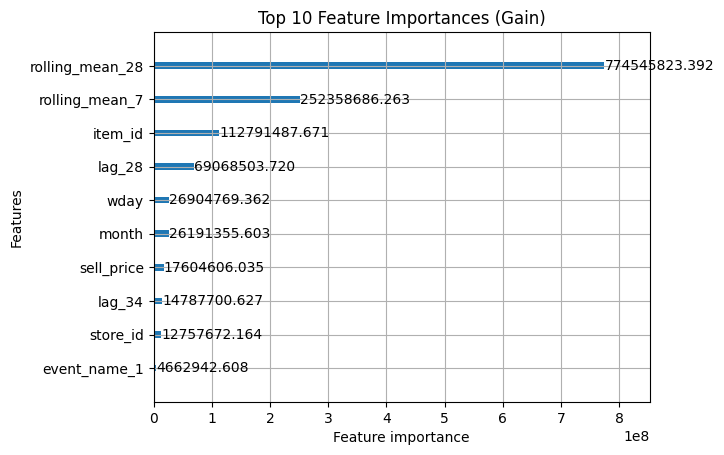

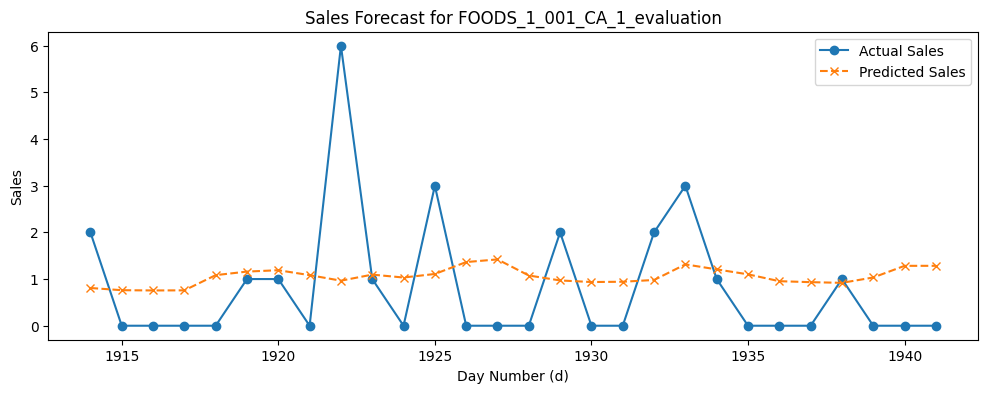

In [ ]:
import matplotlib.pyplot as plt
import lightgbm as lgb

# Plot top 10 most important features
plt.figure(figsize=(10, 6))
lgb.plot_importance(model, max_num_features=10, importance_type='gain')
plt.title('Top 10 Feature Importances (Gain)')
plt.show()
# Create a visual comparison for a single item in the validation set
val_df = df.loc[val_mask].copy()
val_df['sales_pred'] = val_preds

# Pick one item to plot
sample_item = val_df['id'].iloc[0]
sample_data = val_df[val_df['id'] == sample_item].sort_values('d_num')

plt.figure(figsize=(12, 4))
plt.plot(sample_data['d_num'], sample_data['sales'], label='Actual Sales', marker='o')
plt.plot(sample_data['d_num'], sample_data['sales_pred'], label='Predicted Sales', linestyle='--', marker='x')
plt.title(f'Sales Forecast for {sample_item}')
plt.xlabel('Day Number (d)')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [ ]:
# # 1. Install CatBoost if not already installed
# !pip install catboost -q

# import numpy as np
# import pandas as pd
# from catboost import CatBoostRegressor
# from sklearn.metrics import mean_squared_error

# # 2. Define categorical features explicitly for CatBoost
# cat_features = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'event_name_1', 'event_type_1']

# # Ensure categorical columns are converted to string type for CatBoost compatibility
# for col in cat_features:
#     if col in X_train.columns:
#         X_train[col] = X_train[col].astype(str)
#         X_val[col] = X_val[col].astype(str)

# # 3. Initialize CatBoost Regressor
# cb_model = CatBoostRegressor(
#     iterations=800,
#     learning_rate=0.05,
#     depth=6,
#     loss_function='RMSE',
#     eval_metric='RMSE',
#     random_seed=42,
#     task_type='CPU'
# )

# # 4. Fit model
# cb_model.fit(
#     X_train, y_train,
#     cat_features=cat_features,
#     eval_set=(X_val, y_val),
#     early_stopping_rounds=50,
#     verbose=100
# )

# # 5. Predict & Evaluate (Fixed 'x_val' to uppercase 'X_val')
# cb_preds = cb_model.predict(X_val)
# cb_rmse = np.sqrt(mean_squared_error(y_val, cb_preds))
# print(f"CatBoost Validation RMSE: {cb_rmse:.4f}")

# # 6. Ensemble (Blend) LightGBM + CatBoost predictions
# blend_preds = 0.5 * val_preds + 0.5 * cb_preds
# blend_rmse = np.sqrt(mean_squared_error(y_val, blend_preds))
# print(f"Ensemble (LightGBM + CatBoost) RMSE: {blend_rmse:.4f}")

In [ ]:
!pip install pytorch-forecasting pytorch-lightning -q

In [ ]:
import pandas as pd
import numpy as np
import torch
import pytorch_lightning as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

# 1. Filter to 1 store to prevent RAM crash (~3,049 items instead of 30,490)
df_tft = df[df['store_id'] == 'CA_1'].copy()

# 2. Add zero-based integer time index per item group
df_tft['time_idx'] = df_tft['d_num'] - df_tft['d_num'].min()

# 3. Ensure proper data types
cat_cols = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'event_name_1', 'event_type_1']
for col in cat_cols:
    df_tft[col] = df_tft[col].astype(str)

df_tft['sales'] = df_tft['sales'].astype('float32')

# 4. Set prediction and encoder lengths
max_prediction_length = 28
max_encoder_length = 30  # Keep lookback modest to prevent OOM
training_cutoff = df_tft['time_idx'].max() - max_prediction_length

# 5. Build TimeSeriesDataSet
training_dataset = TimeSeriesDataSet(
    df_tft[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="sales",
    group_ids=["id"],
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=["item_id", "dept_id", "cat_id"],
    time_varying_known_categoricals=["event_name_1", "event_type_1"],
    time_varying_known_reals=["wday", "month", "year", "snap_CA", "sell_price"],
    time_varying_unknown_reals=["sales", "lag_28", "rolling_mean_7"],
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

# 6. Create DataLoaders with small batch size for GPU memory safety
validation_dataset = TimeSeriesDataSet.from_dataset(training_dataset, df_tft, predict=True, stop_randomization=True)

train_dataloader = training_dataset.to_dataloader(batch_size=32, shuffle=True, num_workers=2)
val_dataloader = validation_dataset.to_dataloader(batch_size=64, shuffle=False, num_workers=2)

ModuleNotFoundError: No module named 'pytorch_lightning'

In [ ]:
# Create lightweight TFT model
tft = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=0.03,
    hidden_size=16,            # Reduced from default 64 to save GPU memory
    attention_head_size=1,     # Low head count to avoid RAM spikes
    dropout=0.1,
    hidden_continuous_size=8,
    loss=QuantileLoss(),
    reduce_on_plateau_patience=4,
)

# Setup Trainer
trainer = pl.Trainer(
    max_epochs=5,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    gradient_clip_val=0.1,
)

# Train model safely
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate predictions on validation set (returns predictions + features)
raw_predictions = tft.predict(val_dataloader, mode="raw", return_x=True)
predictions = tft.predict(val_dataloader)

# 2. Extract actual values and calculate RMSE
actuals = torch.cat([y[0] for x, y in iter(val_dataloader)])
tft_rmse = np.sqrt(np.mean((predictions.numpy() - actuals.numpy()) ** 2))
print(f"TFT Validation RMSE (Store CA_1): {tft_rmse:.4f}")

# 3. Plot predictions vs actuals for a few random items
for idx in range(3):
    fig, ax = plt.subplots(figsize=(10, 4))
    tft.plot_prediction(raw_predictions.x, raw_predictions.output, idx=idx, add_loss_to_title=True, ax=ax)
    plt.show()